<a href="https://colab.research.google.com/github/Carinaaa/ML-Learning-Path/blob/intro-sklearn/Sklearn_less_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Improving a model

first predictions = baseline predictions

first model = baseline model

From data perspective:
*   Could we collect more data? (generally, the more data, the better)
*   Could we improve the data?

From a model prespective:
*   Is there a better model to use?
*   Could we imprved the current model?

parameters = model finds these patterns in data

hyperparameters = settings on a model you can adjust to (pottentially) improve its ability to find patters

In [1]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.get_params() # get the hyperparameters

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

Three ways to adjust hyperparamters:
1. by hand
2. Randomly with RandomSearchCV
3. Exhaustively with GridSearchCV

## Tuning hyperparameters by hand

We make 3 sets: training, validation and test.

We're going to try to adjust:
*   max_depth
*   max_features
*   min_samples_leaf
*   min_samples_split
*   n_estimators

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_preds(y_true, y_preds):
  """
  Performs evaluation comparison on y_true labels vs. y_pred lebales on a classification.
  """
  accuracy = accuracy_score(y_true, y_preds)
  precision = precision_score(y_true, y_preds)
  recall = recall_score(y_true, y_preds)
  f1 = f1_score(y_true, y_preds)
  metric_dict = {"accuracy": round(accuracy, 2),
                 "precision": round(precision, 2),
                 "recall": round(recall, 2),
                 "f1": round(f1, 2)}

  print(f"Acc: {accuracy * 100:.2f}%")
  print(f"Precision: {precision * 100:.2f}%")
  print(f"Recall: {recall * 100:.2f}%")
  print(f"F1: {f1 * 100:.2f}%")

  return metric_dict

In [3]:
import pandas as pd

https = "https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv"
heart_disease = pd.read_csv(https)
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

np.random.seed(42)

# suffele the data
heart_disease_suffeled = heart_disease.sample(frac=1)

# create X (features matrix)
X = heart_disease_suffeled.drop("target", axis=1)

# create y (labels)
y = heart_disease_suffeled["target"]

# Split the data into train, validation and tests sets
train_split = round(0.7 * len(heart_disease_suffeled)) # 70% of data
valid_split = round(train_split + 0.15 * len(heart_disease_suffeled)) # 15% of data

X_train, y_train = X[:train_split], y[:train_split]
X_valid, y_valid = X[train_split:valid_split], y[train_split:valid_split]
X_test, y_test = X[valid_split:], y[valid_split:]

len(X_train), len(X_valid), len(X_test)

(212, 45, 46)

In [5]:
np.random.seed(42)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Make baseline predictions
y_preds = clf.predict(X_valid)

# Evaluate the classfier on validation set
baseline_metrics = evaluate_preds(y_valid, y_preds)
baseline_metrics

Acc: 82.22%
Precision: 84.00%
Recall: 84.00%
F1: 84.00%


{'accuracy': 0.82, 'precision': 0.84, 'recall': 0.84, 'f1': 0.84}

In [6]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [7]:
np.random.seed(42)

# Create a second classified with different hyperparameters

clf_2 = RandomForestClassifier(n_estimators=200)
clf_2.fit(X_train, y_train)

# Make predictions with different hyperparameters
y_preds_2 = clf_2.predict(X_valid)

# Evaluate the 2nd classifier
clf_2_metrics = evaluate_preds(y_valid, y_preds_2)
clf_2_metrics

Acc: 82.22%
Precision: 81.48%
Recall: 88.00%
F1: 84.62%


{'accuracy': 0.82, 'precision': 0.81, 'recall': 0.88, 'f1': 0.85}

In [8]:
clf_3 = RandomForestClassifier(n_estimators=100, max_depth=5)
clf_3.fit(X_train, y_train)
# Make predicitons
y_preds_3 = clf_3.predict(X_valid)

# Evaluate the 3rd classifier
clf_3_metrics = evaluate_preds(y_valid, y_preds_3)
clf_3_metrics

Acc: 84.44%
Precision: 82.14%
Recall: 92.00%
F1: 86.79%


{'accuracy': 0.84, 'precision': 0.82, 'recall': 0.92, 'f1': 0.87}

## Randomly with RandomSearchCV



In [9]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

grid = {'n_estimators' : [10, 100, 200, 500, 1000, 1200],
        'max_depth' : [None, 5, 10, 20, 30],
        'max_features': ['auto', 'sqrt'],
        'min_samples_split' : [2,4,6],
        'min_samples_leaf': [1,2,4]}

np.random.seed(42)

# Split X & y
X = heart_disease_suffeled.drop("target", axis=1)
y = heart_disease_suffeled["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate RandomForestCasifier
clf = RandomForestClassifier(n_jobs=1) # how much of computer processor to be used

# Setup RandomizedSearchCV
rs_clf = RandomizedSearchCV(estimator=clf,
                            param_distributions=grid,
                            n_iter=10, # the number of models to try
                            cv=5, # cross-validation
                            verbose=2)

rs_clf.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   6.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   3.6s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.1s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=1),
                   param_distributions={'max_depth': [None, 5, 10, 20, 30],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 4, 6],
                                        'n_estimators': [10, 100, 200, 500,
                                                         1000, 1200]},
                   verbose=2)

In [10]:
rs_clf.best_params_

{'n_estimators': 200,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [11]:
# Make prediction with the best params
rs_y_preds = rs_clf.predict(X_test)

# Evaluate the predictions
rs_metrics = evaluate_preds(y_test, rs_y_preds)
rs_metrics


Acc: 81.97%
Precision: 77.42%
Recall: 85.71%
F1: 81.36%


{'accuracy': 0.82, 'precision': 0.77, 'recall': 0.86, 'f1': 0.81}

Hyperparameter tuning with GridSearchCV

In [12]:
grid_2 = {'n_estimators' : [10, 100, 200, 500],
          'max_depth' : [None],
          'max_features': ['auto', 'sqrt'],
          'min_samples_split' : [6],
          'min_samples_leaf': [1,2]}

In [13]:
3*1*2*1*2 *5

60

In [14]:
from sklearn.model_selection import GridSearchCV, train_test_split

np.random.seed(42)

# Split X & y
X = heart_disease_suffeled.drop("target", axis=1)
y = heart_disease_suffeled["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate RandomForestCasifier
clf = RandomForestClassifier(n_jobs=1) # how much of computer processor to be used

# Setup GridSearchCV
gs_clf = GridSearchCV(estimator=clf,
                      param_grid=grid_2,
                      cv=5, # cross-validation
                      verbose=2)

gs_clf.fit(X_train, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=6, n_est

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=1),
             param_grid={'max_depth': [None], 'max_features': ['auto', 'sqrt'],
                         'min_samples_leaf': [1, 2], 'min_samples_split': [6],
                         'n_estimators': [10, 100, 200, 500]},
             verbose=2)

In [16]:
gs_clf.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 6,
 'n_estimators': 500}

In [17]:
gs_y_preds = gs_clf.predict(X_test)

# evaluate the predictions
gs_metrics = evaluate_preds(y_test, gs_y_preds)
gs_metrics


Acc: 81.97%
Precision: 77.42%
Recall: 85.71%
F1: 81.36%


{'accuracy': 0.82, 'precision': 0.77, 'recall': 0.86, 'f1': 0.81}

## Model comparison

<Axes: >

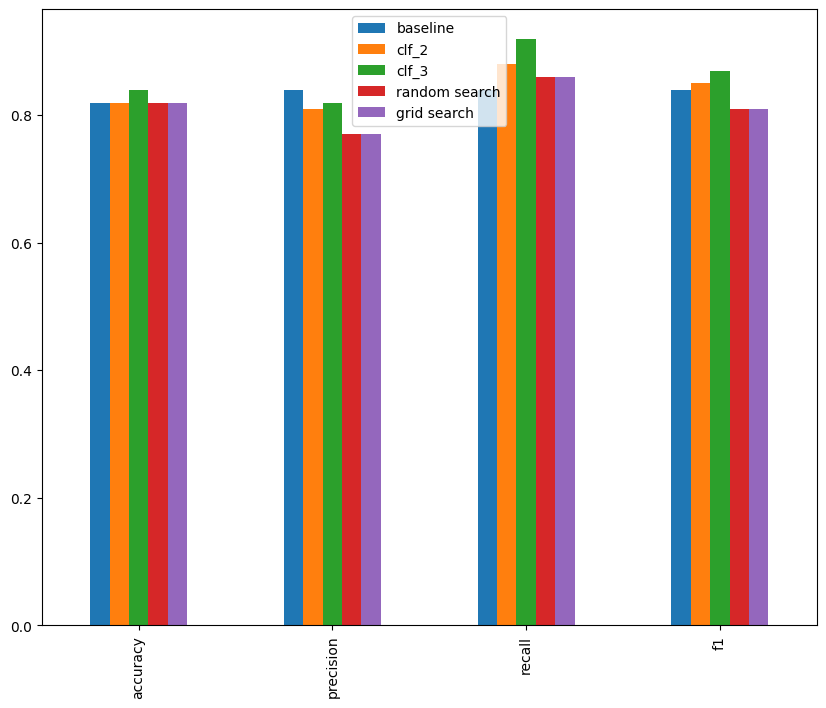

In [18]:
compare_metrics = pd.DataFrame({'baseline': baseline_metrics,
                                "clf_2" : clf_2_metrics,
                                'clf_3' : clf_3_metrics,
                                'random search' : rs_metrics,
                                'grid search' : gs_metrics})

compare_metrics.plot.bar(figsize=(10,8))

## Saving and loading trained machine learning models

Two ways to save and load a machine learning models:

1. With Python pickle module
2. With the joblib module

In [19]:
# Pickle

import pickle

# Save an existing model to file
pickle.dump(gs_clf, open('gs_random_random_fprest_model.pkl', 'wb'))

In [20]:
# Load a save model

loaded_pickle_model = pickle.load(open('gs_random_random_fprest_model.pkl', 'rb'))

In [21]:
# Make some pedictions
pickle_y_preds = loaded_pickle_model.predict(X_test)
evaluate_preds(y_test, pickle_y_preds)

Acc: 81.97%
Precision: 77.42%
Recall: 85.71%
F1: 81.36%


{'accuracy': 0.82, 'precision': 0.77, 'recall': 0.86, 'f1': 0.81}

In [22]:
# joblib

from joblib import dump, load

# Save model to file
dump(gs_clf, filename='gs_random_random_forest_model.joblib')


['gs_random_random_forest_model.joblib']

In [23]:
# load the model
loaded_joblib_model = load(filename='gs_random_random_forest_model.joblib')

In [24]:
predict_joblib = loaded_joblib_model.predict(X_test)
evaluate_preds(y_test, predict_joblib)

Acc: 81.97%
Precision: 77.42%
Recall: 85.71%
F1: 81.36%


{'accuracy': 0.82, 'precision': 0.77, 'recall': 0.86, 'f1': 0.81}